Data agumentation

In [ ]:
import tensorflow as tf
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
import matplotlib.pyplot as plt

img = load_img('/content/dog.png')
x = img_to_array(img)
x = x.reshape((1,)+x.shape)

i = 0
for batch in datagen.flow(x,batch_size=1,save_to_dir='/content', save_prefix='dog', save_format='jpeg'):
  i += 1
  if i >= 20 :
    break

In [ ]:
# displaying the images

i = 0
for batch in datagen.flow(x,batch_size=1,save_to_dir='/content', save_prefix='dog', save_format='jpeg'):
  i += 1
  if i >= 20 :
    break

  plt.imshow(array_to_img(batch[0]))
  plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
img = load_img('/content/mayank.png')
x = img_to_array(img)
x = x.reshape((1,)+x.shape)

i = 0
for batch in datagen.flow(x,batch_size=1,save_to_dir='/content', save_prefix='mayank', save_format='jpeg'):
  i += 1
  if i >= 20 :
    break

  plt.imshow(array_to_img(batch[0]))
  plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import keras
from keras import layers

In [ ]:
def customVG11(input_shape=(224,224,3),n_class=10):

  inputs = layers.Input(shape=input_shape)

  # block1
  x = layers.Conv2D(64,kernel_size=(3,3),padding='same',activation='relu')(inputs)
  x = layers.MaxPool2D(pool_size=(2,2),strides=(2,2))(x)

  # block2
  x = layers.Conv2D(128,kernel_size=(3,3),padding='same',activation='relu')(x)
  x = layers.MaxPool2D(pool_size=(2,2),strides=(2,2))(x)

  # block3
  x = layers.Conv2D(256,kernel_size=(3,3),padding='same',activation='relu')(x)
  x = layers.Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu')(x)
  x = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)

  # Block 4
  x = layers.Conv2D(512, kernel_size=(3, 3), padding='same', activation='relu')(x)
  x = layers.Conv2D(512, kernel_size=(3, 3), padding='same', activation='relu')(x)
  x = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)

  # block 5
  x = layers.Conv2D(512, kernel_size=(3, 3), padding='same', activation='relu')(x)
  x = layers.Conv2D(512, kernel_size=(3, 3), padding='same', activation='relu')(x)
  x = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)

  # fully connected layer
  x = layers.Flatten()(x) # Converts 7x7x512 matrix into a 1D vector
  x = layers.Dense(4096, activation='relu')(x)
  x = layers.Dropout(0.5)(x)
  x = layers.Dense(4096, activation='relu')(x)
  x = layers.Dropout(0.5)(x)

  # Output layer: uses Softmax for multi-class classification probability distribution
  outputs = layers.Dense(n_class, activation='softmax')(x)

  # Construct the model graph
  model = keras.Model(inputs=inputs, outputs=outputs, name="Custom_VGG11")
  return model

In [ ]:
model = customVG11()

# Print out the text blueprint table
model.summary()

Model: "Custom_VGG11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,807,306 (491.36 MB)

 Trainable params: 128,807,306 (491.36 MB)

 Non-trainable params: 0 (0.00 B)

In [1]:
# functional apis using keras for non linearity
from keras.models import Model
from keras.layers import *

x = Input(shape=(28,28,1))

hidden1 = Dense(128,activation='relu')(x)
hidden2 = Dense(64,activation='relu')(hidden1)

output1 = Dense(1,activation='linear')(hidden2)
output2 = Dense(10,activation='softmax')(hidden2)

model = Model(inputs=x, outputs=[output1,output2])

In [3]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 28, 28,    │        256 │ input_layer[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 28, 28,    │      8,256 │ dense[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 28, 28, 1) │         65 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 28, 28,    │        650 │ dense_1[0][0]     │
│                     │ 10)               │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,227 (36.04 KB)

 Trainable params: 9,227 (36.04 KB)

 Non-trainable params: 0 (0.00 B)

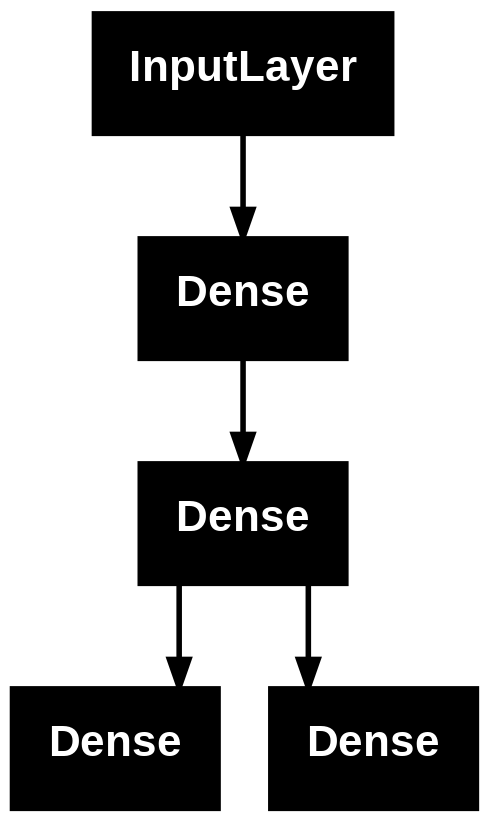

In [4]:
from keras.utils import plot_model
plot_model(model)

In [10]:
inputA = Input(shape=(20,))
inputB = Input(shape=(28,))

x = Dense(8,activation='relu')(inputA)
x1 = Dense(4,activation='relu')(x)

y = Dense(64,activation='relu')(inputB)
y1 = Dense(32,activation='relu')(y)
y2 = Dense(16,activation='relu')(y1)

combined = Concatenate()([x1,y2])

z = Dense(2,activation='relu')(combined)
z1 = Dense(1,activation='relu')(z)

model = Model(inputs=[inputA,inputB],outputs=z1)

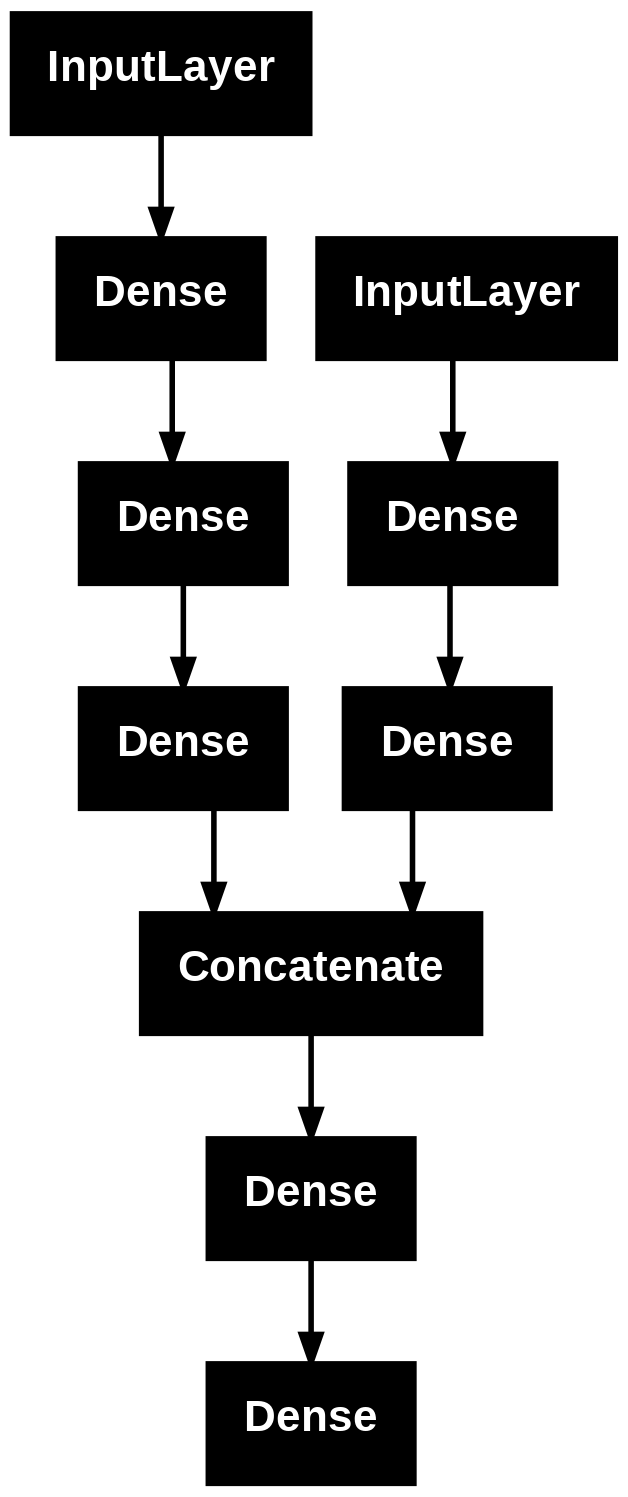

In [11]:
plot_model(model)

In [12]:
 !mkdir -p ~/.kaggle
 !cp kaggle.json ~/.kaggle/

In [13]:
!kaggle datasets download -d jangedoo/utkface-new

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
100% 331M/331M [00:04<00:00, 81.7MB/s]



In [14]:
import zipfile
zip_ref = zipfile.ZipFile('/content/utkface-new.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [16]:
import numpy as np
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

folder_path = '/content/utkface_aligned_cropped/UTKFace'

In [17]:
age = []
gender = []
img_path = []

for file in os.listdir(folder_path):
  age.append(int(file.split('_')[0]))
  gender.append(int(file.split('_')[1]))
  img_path.append(file)

In [18]:
len(age)

23708

In [19]:
import pandas as pd
df = pd.DataFrame({'age':age,'gender':gender,'file_path':img_path})

In [20]:
df.head()

,age,gender,file_path
0,22,1,22_1_1_20170112230505525.jpg.chip.jpg
1,18,0,18_0_2_20170110231202841.jpg.chip.jpg
2,26,1,26_1_4_20170117201548014.jpg.chip.jpg
3,23,1,23_1_3_20170104222242439.jpg.chip.jpg
4,5,1,5_1_2_20161219142215457.jpg.chip.jpg


In [21]:
df.shape

(23708, 3)

In [22]:
train_df = df.sample(frac=1,random_state=0).iloc[:20000]
test_df = df.sample(frac=1,random_state=0).iloc[20000:]

train_df.shape , test_df.shape

((20000, 3), (3708, 3))

In [23]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

In [25]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory=folder_path,
    x_col='file_path',
    y_col=['age','gender'],
    target_size=(200,200),
    class_mode='multi_output',
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    directory=folder_path,
    x_col='file_path',
    y_col=['age','gender'],
    target_size=(200,200),
    class_mode='multi_output',
)

Found 20000 validated image filenames.
Found 3708 validated image filenames.


In [26]:
from keras.applications.vgg16 import VGG16
from keras.layers import *
from keras.models import Model

vggnet = VGG16(include_top=False,input_shape=(200,200,3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [28]:
vggnet.trainable = False
output = vggnet.layers[-1].output

flatten = Flatten()(output)

dense1 = Dense(512,activation='relu')(flatten)
dense2 = Dense(512,activation='relu')(flatten)

dense3 = Dense(512,activation='relu')(dense1)
dense4 = Dense(512,activation='relu')(dense2)

output1 = Dense(1,activation='linear',name='age')(dense3)
output2 = Dense(1,activation='sigmoid',name='gender')(dense4)

model = Model(inputs=vggnet.input,outputs=[output1,output2])

In [29]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 200, 200,  │      1,792 │ input_layer_11[0… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 200, 200,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 100, 100,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 100, 100,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 100, 100,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 50, 50,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 50, 50,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 50, 50,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 50, 50,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 25, 25,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 25, 25,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 25, 25,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 25, 25,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 12, 12,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 12, 12,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 12, 12,    │  2,359,808 │ block5_conv1[0][

 Total params: 34,116,418 (130.14 MB)

 Trainable params: 19,401,730 (74.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

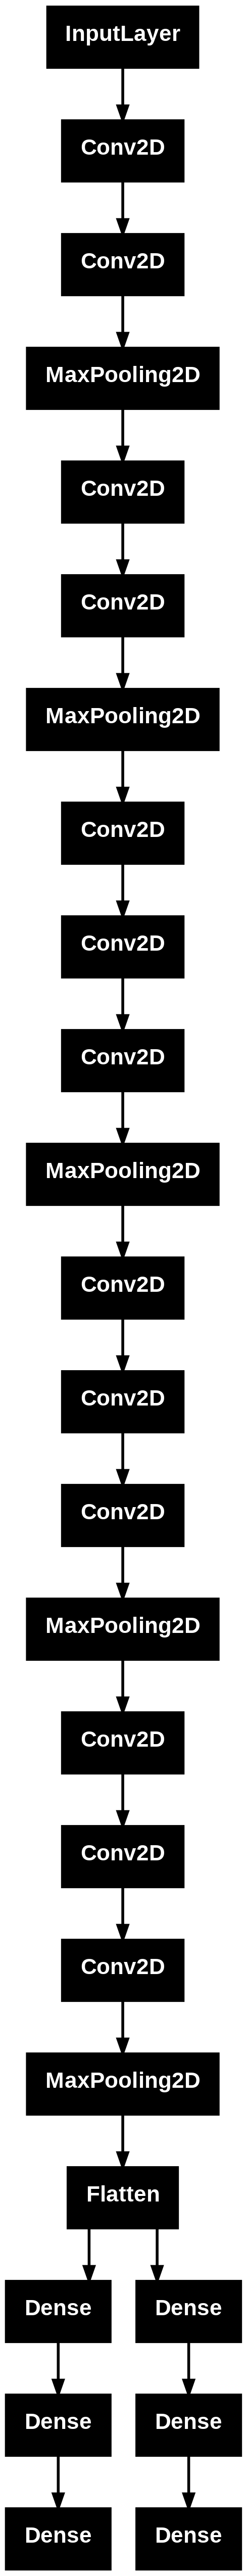

In [30]:
plot_model(model)

In [31]:
model.compile(
    optimizer='adam',
    loss={
        'age':'mae',
        'gender':'binary_crossentropy'
    },
    metrics={
        'age':'mae',
        'gender':'accuracy'
    }
)

In [40]:
import tensorflow as tf

# Define the output signature for the generator that yields (images, (age_labels, gender_labels))
output_signature = (
    tf.TensorSpec(shape=(None, 200, 200, 3), dtype=tf.float32),
    (
        tf.TensorSpec(shape=(None,), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.float32)
    )
)

def format_generator_output(generator):
    for x, y in generator:
        # Convert list of labels to a tuple of labels
        yield x, tuple(y)

train_dataset = tf.data.Dataset.from_generator(
    lambda: format_generator_output(train_generator),
    output_signature=output_signature
)

test_dataset = tf.data.Dataset.from_generator(
    lambda: format_generator_output(test_generator),
    output_signature=output_signature
)

steps_per_epoch = len(train_generator)
validation_steps = len(test_generator)
model.fit(train_dataset, epochs=10, validation_data=test_dataset, steps_per_epoch=steps_per_epoch, validation_steps=validation_steps)

Epoch 1/10


InvalidArgumentError: Graph execution error:

Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
TypeError: `generator` yielded an element of shape (32,) where an element of shape (None, 1) was expected.
Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/ops/script_ops.py", line 269, in __call__
    ret = func(*args)
          ^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/autograph/impl/api.py", line 643, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/from_generator_op.py", line 235, in generator_py_func
    raise TypeError(

TypeError: `generator` yielded an element of shape (32,) where an element of shape (None, 1) was expected.


	 [[{{node PyFunc}}]]
	 [[IteratorGetNext]] [Op:__inference_multi_step_on_iterator_4362]